In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


from sklearn.metrics import recall_score, precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

import pandas as pd
import numpy as np

import sklearn.metrics as metrics

from sklearn.feature_selection import SequentialFeatureSelector as SFS

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from scipy import stats

## Load dữ liệu
---

In [1]:
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
df.head()

NameError: name 'pd' is not defined

## Làm sạch dữ liệu
---

In [5]:
# Kiểm tra các giá trị trùng lăp
# In ra tổng các hàng trong dữ liệu
print('Tổng số hàng:', df.shape[0])
print('Các giá trị trùng lăp:', df.duplicated().sum())

Tổng số hàng: 70692
Các giá trị trùng lăp: 1635


#### Có thể thấy dữ liệu đang có 1635 hàng trùng lặp nên tiến hành xóa các giá trị trùng lặp để tránh ảnh hướng xấu đến mô hình

In [8]:
# Kiểm tra các giá trị trùng lăp
# In ra tổng các hàng trong dữ liệu
print('Tổng số hàng:', df.shape[0])
print('Các giá trị trùng lăp:', df.duplicated().sum())

Tổng số hàng: 70692
Các giá trị trùng lăp: 1635


### Kiểm tra các giá trị trùng lặp có thể nhận thấy dữ liệu đang có giá trị trùng lặp cần xử lý

In [13]:
# Xóa giá trị trùng lặp
df.drop_duplicates(inplace=True) 
print('Tổng số hàng còn lại sau khi xóa: ', df.shape[0])

Tổng số hàng còn lại sau khi xóa:  69057


### Check lại dữ liệu sau khi xóa

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69057 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       69057 non-null  float64
 1   HighBP                69057 non-null  float64
 2   HighChol              69057 non-null  float64
 3   CholCheck             69057 non-null  float64
 4   BMI                   69057 non-null  float64
 5   Smoker                69057 non-null  float64
 6   Stroke                69057 non-null  float64
 7   HeartDiseaseorAttack  69057 non-null  float64
 8   PhysActivity          69057 non-null  float64
 9   Fruits                69057 non-null  float64
 10  Veggies               69057 non-null  float64
 11  HvyAlcoholConsump     69057 non-null  float64
 12  AnyHealthcare         69057 non-null  float64
 13  NoDocbcCost           69057 non-null  float64
 14  GenHlth               69057 non-null  float64
 15  MentHlth              69

#### Kiểm tra thông tin của bộ dữ liệu có thế thấy các hàng không có giá trị thiếu và kiểu dữ liệu của bộ dữ liệu cũng đã đồng nhất

In [19]:
# Kiểm tra tính đồng nhất của các cột
unique_counts = df.nunique()
print(unique_counts)

Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64


#### Kiểm tra tính đồng nhất của các cột dữ liệu thì có thể thấy dữ liệu đã đúng với mô tả không có cột nào chưa đồng nhất 

array([[<Axes: title={'center': 'Diabetes_binary'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>],
       [<Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>],
       [<Axes: title={'center': 'MentHlth'}>,
        <Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title=

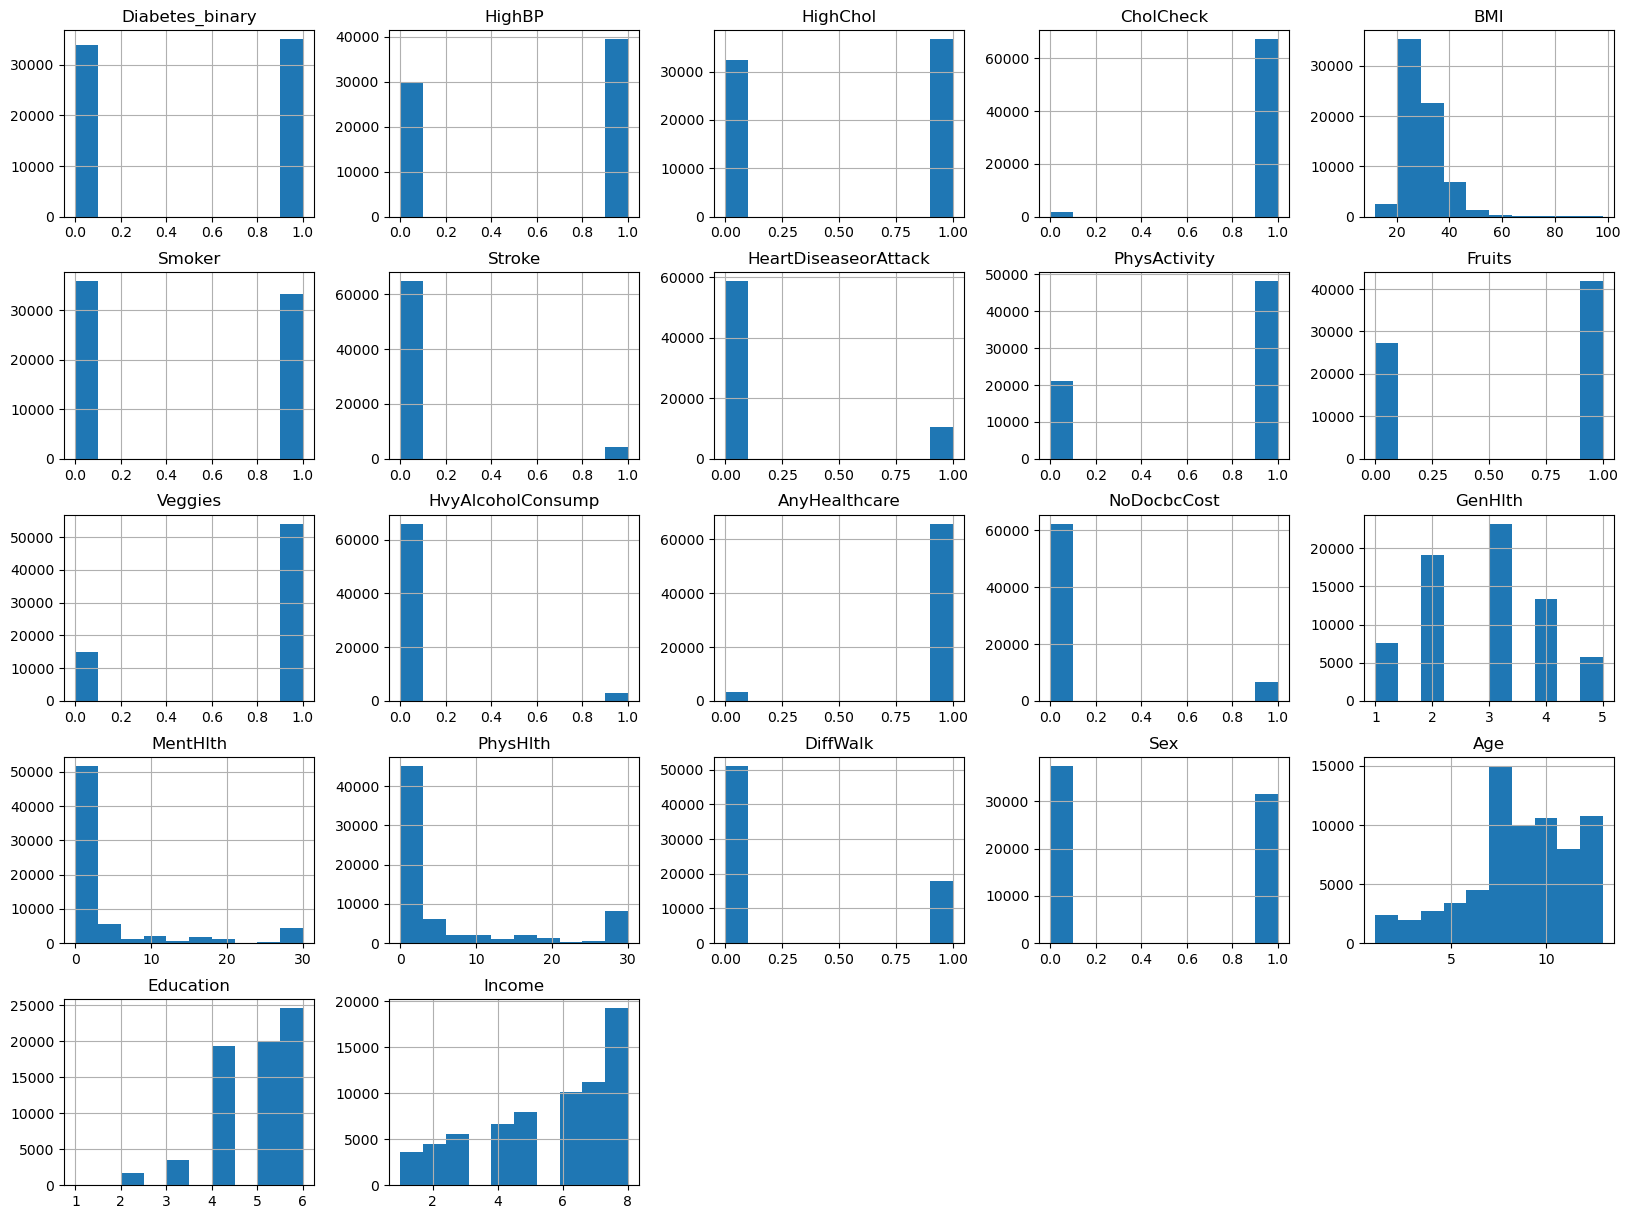

In [22]:
df.hist(figsize=(20, 15))

#### Kiểm tra phân phối của các cột dữ liệu có thể thấy rằng một số cột đang có phân phối dữ liệu không đều và cột BMI đang có dấu hiệu bất thường

In [24]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,...,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000
mean,0.508232,0.571224,0.531329,0.974803,29.955834,0.481935,0.063643,0.150875,0.696483,0.605659,...,0.953908,0.096138,2.863692,3.840103,5.945306,0.258612,0.456464,8.604037,4.900285,5.651332
std,0.499936,0.494905,0.499021,0.156723,7.147972,0.499677,0.244118,0.357930,0.459780,0.488712,...,0.209687,0.294782,1.107950,8.231164,10.139113,0.437875,0.498105,2.858284,1.029338,2.175608
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,1.000000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,3.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


#### Kiểm tra lại thì có thể thấy rằng cột BMI đang có giá trị ngoại lai 

<Axes: ylabel='Count'>

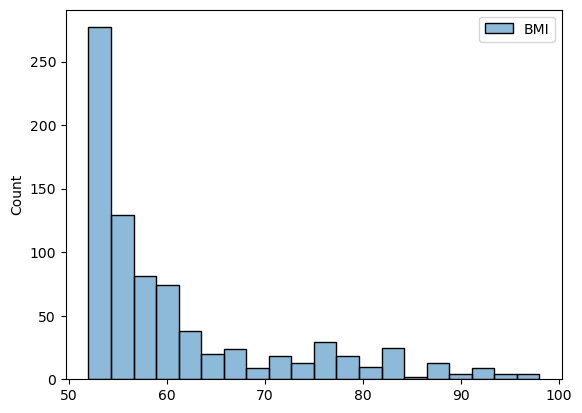

In [26]:
# Tính toán z-score cho cột BMI
df['z_score_bmi'] = stats.zscore(df['BMI'], ddof=1)

# Lọc ra các giá trị ngoại lai trong cột BMI
data_outliers= df[(df['z_score_bmi'] > 3) | (df['z_score_bmi'] < -3)][['z_score_bmi']]

# In ra giá trị của cột BMI của các giá trị ngoại lai
sns.histplot(df[(df['z_score_bmi'] > 3) | (df['z_score_bmi'] < -3)][['BMI']])


In [27]:
print(f"Số lượng giá trị ngoại lai: {len(data_outliers)}")
outlier_ratio = len(data_outliers) / 69057
print(f"Tỷ lệ giá trị ngoại lai: {outlier_ratio:.2%}")

Số lượng giá trị ngoại lai: 801
Tỷ lệ giá trị ngoại lai: 1.16%


#### Trong thực tế mặc dù rất hiếm nhưng vẫn có người BMI từ 50 - 100, các giá trị ngoại lai cũng chỉ chiểm hơn 1% trong cột dữ liệu nên sẽ không ảnh hưởng nhiều đến mô hình. Ngoài ra việc giữ lại những chỉ số này cũng làm đa dạng hơn cho mô hình phản ánh đúng với thực tế

In [29]:
df.drop(columns=['z_score_bmi'], inplace=True)

#### Xóa cột z_score_bmi sau khi đã xong bước kiểm tra ngoại lai

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69057 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       69057 non-null  float64
 1   HighBP                69057 non-null  float64
 2   HighChol              69057 non-null  float64
 3   CholCheck             69057 non-null  float64
 4   BMI                   69057 non-null  float64
 5   Smoker                69057 non-null  float64
 6   Stroke                69057 non-null  float64
 7   HeartDiseaseorAttack  69057 non-null  float64
 8   PhysActivity          69057 non-null  float64
 9   Fruits                69057 non-null  float64
 10  Veggies               69057 non-null  float64
 11  HvyAlcoholConsump     69057 non-null  float64
 12  AnyHealthcare         69057 non-null  float64
 13  NoDocbcCost           69057 non-null  float64
 14  GenHlth               69057 non-null  float64
 15  MentHlth              69

### Kiểm tra thông tin của bộ dữ liệu có thế thấy các hàng không có giá trị thiếu và kiểu dữ liệu của bộ dữ liệu cũng đã đồng nhất¶

## Feature Creation 
---

In [34]:
df_new = df.copy()

df_new['BMI_Age'] = df_new['BMI'] * df_new['Age']
df_new['GenHlth_PhysActivity'] = df_new['GenHlth'] * df_new['PhysActivity']
df_new['Ment_Phys_Health_Score'] = df_new['MentHlth'] + df_new['PhysHlth']

df_new.drop(columns=['BMI', 'Age', 'GenHlth', 'PhysActivity', 'MentHlth', 'PhysHlth'], inplace=True)

In [35]:
df_new.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Education,Income,BMI_Age,GenHlth_PhysActivity,Ment_Phys_Health_Score
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,6.0,8.0,104.0,3.0,35.0
1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,6.0,8.0,312.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,6.0,8.0,338.0,1.0,10.0
3,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,6.0,8.0,308.0,3.0,3.0
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,5.0,8.0,232.0,2.0,0.0


In [36]:
unique_counts = df_new.nunique()
print(unique_counts)

Diabetes_binary             2
HighBP                      2
HighChol                    2
CholCheck                   2
Smoker                      2
Stroke                      2
HeartDiseaseorAttack        2
Fruits                      2
Veggies                     2
HvyAlcoholConsump           2
AnyHealthcare               2
NoDocbcCost                 2
DiffWalk                    2
Sex                         2
Education                   6
Income                      8
BMI_Age                   431
GenHlth_PhysActivity        6
Ment_Phys_Health_Score     61
dtype: int64


#### BMI × Age: Biến số biểu thị ảnh hưởng của chỉ số khối cơ thể theo độ tuổi.<br>GenHlth × PhysActivity: Mức độ sức khỏe chung kết hợp với mức độ vận động thể chất.<br>Ment_Phys_Health_Score: Tổng hợp sức khỏe tâm lý và thể chất.<br>
#### Copy một biến lưu dữ liệu mới để giữ lại các biến đặc trưng của tệp dữ liệu cũ

In [38]:
X_old = df.drop('Diabetes_binary', axis=1)
y_old = df['Diabetes_binary']

X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(X_old, y_old, test_size=0.3, random_state=42)

X_new = df_new.drop('Diabetes_binary', axis=1)
y_new = df_new['Diabetes_binary']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

#### Chia tệp dữ liệu cũ và tệp dữ liệu mới khi thêm biến mới để thử nghiệm 

In [42]:
# Huấn luyện mô hình trước khi tạo biến mới
model_old = GaussianNB()
model_old.fit(X_train_old, y_train_old)
y_pred_old = model_old.predict(X_test_old)

# Huấn luyện mô hình sau khi ta đã tạo biến mới
model_new = GaussianNB()
model_new.fit(X_train_new, y_train_new)
y_pred_new = model_new.predict(X_test_new)

# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_all = recall_score(y_test_old, y_pred_old)
precision_all = precision_score(y_test_old, y_pred_old)
f1_all = f1_score(y_test_old, y_pred_old)
accuracy_all = accuracy_score(y_test_old, y_pred_old)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_selected = recall_score(y_test_new, y_pred_new)
precision_selected = precision_score(y_test_new, y_pred_new)
f1_selected = f1_score(y_test_new, y_pred_new)
accuracy_selected = accuracy_score(y_test_new, y_pred_new)

# So sánh kết quả
comparison = pd.DataFrame({
    'Model': ['OLD', 'NEW'],
    'Recall': [recall_all, recall_selected],
    'Precision': [precision_all, precision_selected],
    'F1 Score': [f1_all, f1_selected],
    'Accuracy': [accuracy_all, accuracy_selected]
})

print(comparison)

  Model    Recall  Precision  F1 Score  Accuracy
0   OLD  0.713059   0.729511  0.721191  0.717975
1   NEW  0.739196   0.717859  0.728372  0.717975


## Feature Transformation
---

array([[<Axes: title={'center': 'BMI_Age'}>,
        <Axes: title={'center': 'Ment_Phys_Health_Score'}>],
       [<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'GenHlth_PhysActivity'}>, <Axes: >]],
      dtype=object)

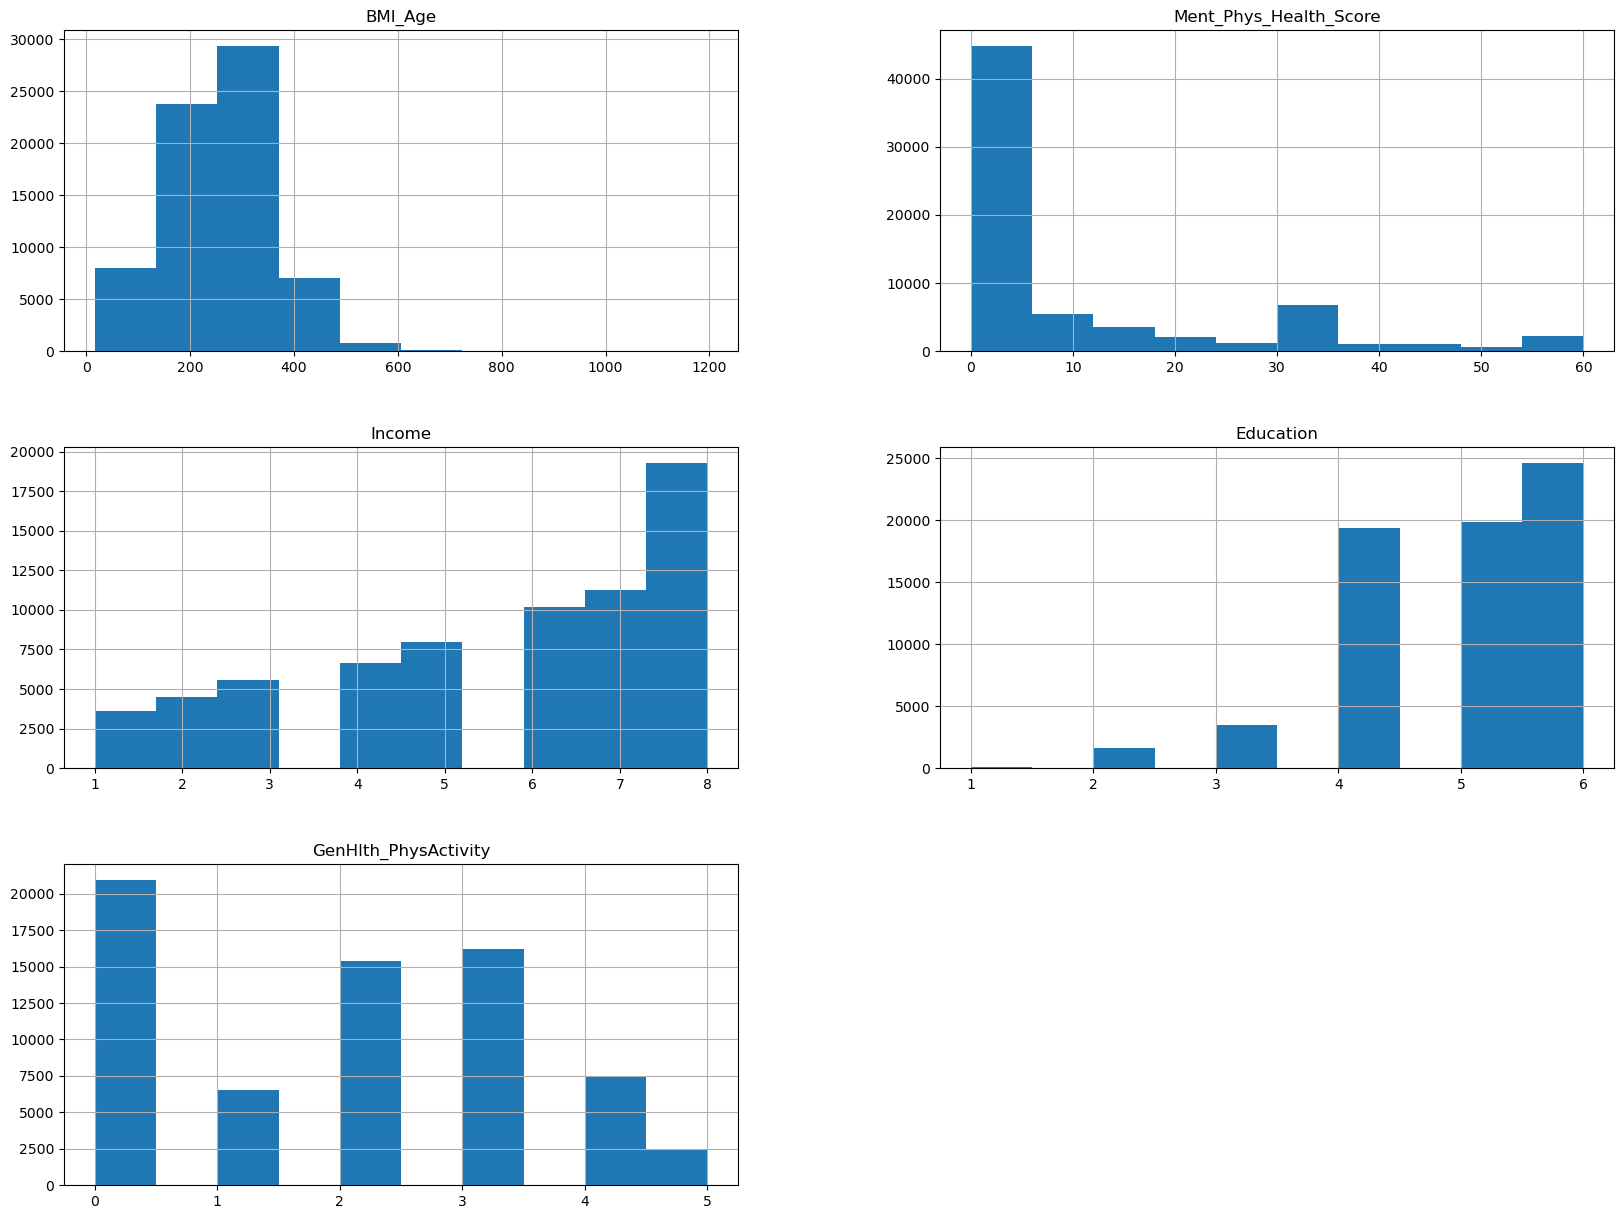

In [53]:
df_new.hist(['BMI_Age', 'Ment_Phys_Health_Score', 'Income', 'Education', 'GenHlth_PhysActivity'], figsize=(20, 15))

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler_stand = StandardScaler()
df_new[['BMI_Age']] = scaler_stand.fit_transform(df_new[['BMI_Age']])

scaler_nomal = MinMaxScaler()
df_new[['HighBP', 'Ment_Phys_Health_Score', 'Education', 'Income','GenHlth_PhysActivity']] = scaler_nomal.fit_transform(df_new[['HighBP', 'Ment_Phys_Health_Score' ,'Education', 'Income','GenHlth_PhysActivity']])

df_new.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Education,Income,BMI_Age,GenHlth_PhysActivity,Ment_Phys_Health_Score
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,-1.526696,0.6,0.583333
1,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.551270,0.0,0.000000
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.811015,0.2,0.166667
3,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.511309,0.6,0.050000
4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.8,1.0,-0.247948,0.4,0.000000


## Xây dựng mô hình Naive Bayes
---

In [61]:
X = df_new.drop("Diabetes_binary", axis=1)
y = df_new["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Huấn luyện mô hình Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_test_pred = model.predict(X_test)
# Dự đoán trên tập huấn luyện
y_train_pred = model.predict(X_train)

### Xây dựng mô hình Naive Bayes và chia tập dữ liệu train và test với tỉ lệ là 0.3
### Tính toán giá trị dự đoán trên cả 2 tập test và train

Text(0.5, 1.0, 'Confusion Matrix Train ')

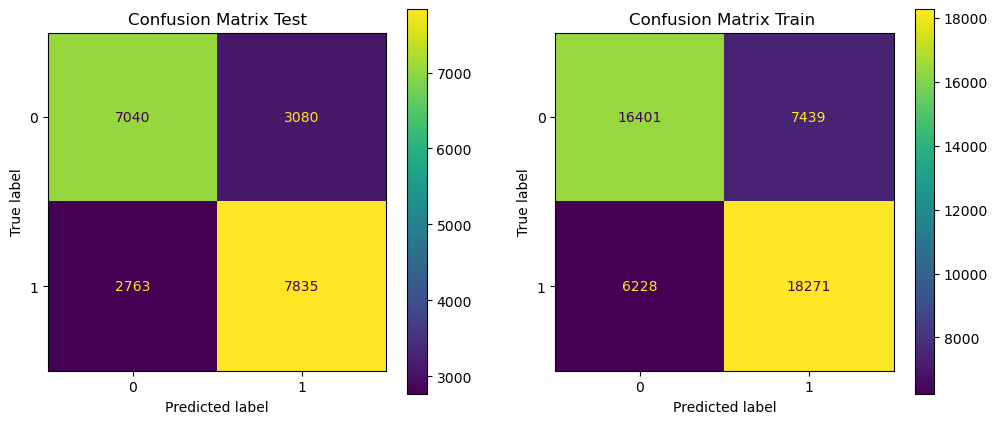

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for test set
cm = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_test.plot(ax=axes[0])
axes[0].set_title('Confusion Matrix Test')

# Plot confusion matrix for train set
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axes[1])
axes[1].set_title('Confusion Matrix Train ')


In [70]:
# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_test = recall_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_train = recall_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train= f1_score(y_train, y_train_pred)
accuracy_train = accuracy_score(y_train, y_train_pred)

# So sánh kết quả
comparison = pd.DataFrame({
    '': ['Test' , 'Train'],
    'Recall': [recall_test, recall_train],
    'Precision': [precision_test, precision_train],
    'F1 Score': [f1_test, f1_train],
    'Accuracy': [accuracy_test, accuracy_train]
})

print(comparison)

            Recall  Precision  F1 Score  Accuracy
0   Test  0.739290   0.717820  0.728397  0.717975
1  Train  0.745786   0.710657  0.727798  0.717268


### Qua biểu đồ Confusion Matrix chúng ta có thể thấy dữ liệu dự đoán có độ chính xác không cao cho lắm, và có thể thấy với các dự đoán có bệnh tiểu đường thì khả năng đúng cao hơn khi dự đoán không bị

### Các thông số chỉ số cơ bản của tập dữ liệu kiểm tra
### Chúng ta có thể thấy chỉ số quan trọng và mục tiêu của mô hình này là chỉ số F1 để có thể dự đoán chính xác sớm xem người đó có bị tiểu đường hay không


### Các thông số chỉ số cơ bản của tập dữ liệu huấn luyện
### So sánh các chỉ số của tập dữ liệu kiểm tra chúng ta có thể thấy rằng mô hình không bị overfitting

### Nhưng chúng ta thấy các chỉ số của mô hình, quan trọng nhất của mô hình là F1 còn khá thấp nên chúng ta sẽ sử dụng thêm nhiều kỹ thuật khác để có thể cải thiện mô hình.

### Các thông số chỉ số cơ bản của tập dữ liệu kiểm tra
### Chúng ta có thể thấy mô hình sau khi được chuẩn hóa không tác động quá rõ đối với tập dữ liệu khi chưa được chuẩn hóa

### Mô hình vẫn không bị overfitting nên có thể tin tưởng, nhưng do độ chính xác hơi thấp và F1 cũng không quá cao nên mô hình có thể dự đoán sai khá nhiều

### Điều đó chúng ta cần có thêm giải pháp nữa là sử dụng Feature Selection với kỹ thuật là Forward Selection để có thể chọn ra được biến tốt nhất cho mô hình

## Hyperparameter Tuning 
---

### Forward Selection 
---

In [75]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = GaussianNB()

# Forward Selection
sfs = SFS(model,
          k_features=10,  # Số đặc trưng cần chọn
          forward=True,   # True: Forward Selection
          floating=False, # False: Không dùng phương pháp floating
          scoring='accuracy', 
          cv=5)           # Cross-validation với 5 lần gập

sfs = sfs.fit(X_train, y_train)

selected_features = list(sfs.k_feature_names_)
print("Selected features:", selected_features)


E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `para

Selected features: ['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'Fruits', 'HvyAlcoholConsump', 'Sex', 'Education', 'Income', 'BMI_Age', 'GenHlth_PhysActivity']


### Sau khi thực hiện xong kỹ thuật Feature Selection em có tìm ra được 10 biến thích hợp nhất để có thể đưa vào Huấn luyện như trên

In [77]:
selected_features.append('Diabetes_binary')

### Thêm cột Diabetes_binary vào danh mục cho dataframe

In [86]:
X = df_new[['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'Fruits', 'HvyAlcoholConsump', 'Sex', 'Education', 'Income', 'BMI_Age', 'GenHlth_PhysActivity']]
y = df_new['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Huấn luyện mô hình Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_test_pred_selection = model.predict(X_test)
# Dự đoán trên tập huấn luyện
y_train_pred_selection = model.predict(X_train)


Text(0.5, 1.0, 'Confusion Matrix Train ')

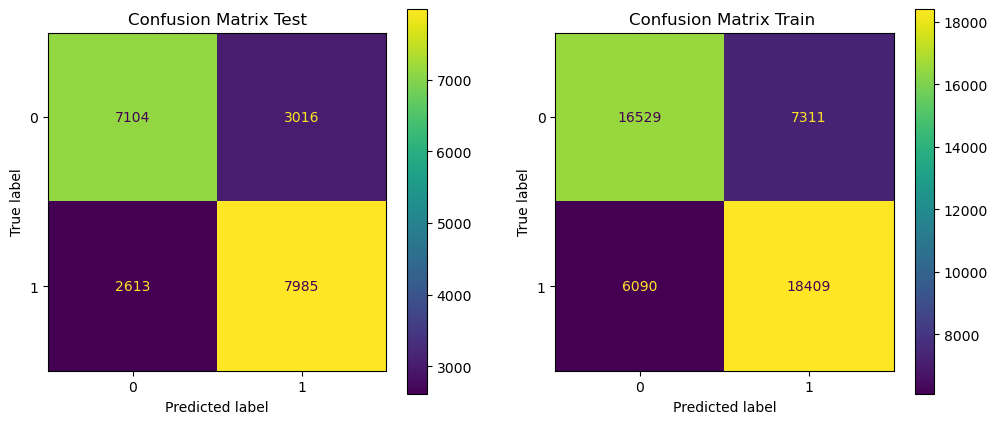

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for test set
cm = confusion_matrix(y_test, y_test_pred_selection)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_test.plot(ax=axes[0])
axes[0].set_title('Confusion Matrix Test')

# Plot confusion matrix for train set
cm_train = confusion_matrix(y_train, y_train_pred_selection)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axes[1])
axes[1].set_title('Confusion Matrix Train ')

In [92]:
# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_test = recall_score(y_test, y_test_pred_selection)
precision_test = precision_score(y_test, y_test_pred_selection)
f1_test = f1_score(y_test, y_test_pred_selection)
accuracy_test = accuracy_score(y_test, y_test_pred_selection)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_train = recall_score(y_train, y_train_pred_selection)
precision_train = precision_score(y_train, y_train_pred_selection)
f1_train= f1_score(y_train, y_train_pred_selection)
accuracy_train = accuracy_score(y_train, y_train_pred_selection)

# So sánh kết quả
comparison = pd.DataFrame({
    '': ['Test' , 'Train'],
    'Recall': [recall_test, recall_train],
    'Precision': [precision_test, precision_train],
    'F1 Score': [f1_test, f1_train],
    'Accuracy': [accuracy_test, accuracy_train]
})

print(comparison)

            Recall  Precision  F1 Score  Accuracy
0   Test  0.753444   0.725843  0.739386  0.728304
1  Train  0.751418   0.715747  0.733149  0.722770


### Các thông số chỉ số cơ bản của tập dữ liệu kiểm tra

### Ở đây chúng ta thấy sau khi áp dụng Feature Selection chúng ta có thể thấy mô hình đang có chuyển biến tăng khá là nhiều và khá là tốt, mô hình cho thấy sự đồng đều

### Chỉ số F1 chưa ở mức cao nhưng cũng khá ổn có sự cân bằng giữa Precision và Recall khá tốt